## DATA 622 - Assignment 2: Experimentation & Model Training

### Introduction

In Machine Learning, Experimentation refers to the systematic process of designing, executing, and analyzing different configurations to identify the optimal settings that performs best on a given task. Experimentation is learning by doing. It involves systematically changing parameters, evaluating results with metrics, and comparing different approaches to find the best solution; essentially, it's the practice of testing and refining machine learning models through controlled experiments to improve their performance.

The key is to modify only one or a few variables at a time to isolate the impact of each change and understand its effect on model performance. In the assignment you will conduct at least 6 experiments. In real life, data scientists run anywhere from a dozen to hundreds of experiments (depending on the dataset and problem domain). 

### Assignment

This assignment consists of conducting at least two (2) experiments for different algorithms: Decision Trees, Random Forest and Adaboost. That is, at least six (6) experiments in total (3 algorithms x 2 experiments each). For each experiment you will define what you are trying to achieve (before each run), conduct the experiment, and at the end you will review how your experiment went. These experiments will allow you to compare algorithms and choose the optimal model. 

### Algorithm Selection

Using the dataset and EDA from the previous assignment, perform the following: You will perform experiments using the following algorithms:
- Decision Trees
- Random Forest
- Adaboost

### Experiment 
For each of the algorithms (above), perform at least two (2) experiments. In a typical experiment you should:
- Define the objective of the experiment (hypothesis)
- Decide what will change, and what will stay the same
- Select the evaluation metric (what you want to measure)
- Perform the experiment
- Document the experiment so you compare results (track progress)

### Variations
There are many things you can vary between experiments, here are some examples:
- Data sampling  (feature selection)
- Data augmentation e.g., regularization, normalization, scaling
- Hyperparameter optimization (you decide, random search, grid search, etc.) 
- Decision Tree breadth & depth (this is an example of a hyperparameter)
- Evaluation metrics e.g., Accuracy, precision, recall, F1-score, AUC-ROC
- Cross-validation strategy e.g., holdout, k-fold, leave-one-out
- Number of trees (for ensemble models) 
- Train-test split: Using different data splits to assess model generalization ability


In [2]:
## load modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import seaborn as sns
import plotly.express as px
import matplotlib.dates as mdates

## load decision tree modules
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

## Load Data

In [3]:
bank_full_url = 'https://raw.githubusercontent.com/eddiexunyc/ml_big_data_work/refs/heads/main/Assignment%201/bank/bank-full.csv'
bank_full = pd.read_csv(bank_full_url, sep=';')
bank_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [4]:
bank_full.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## Exploratory Data Analysis

In [5]:
bank_full.describe().T

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


In [6]:
# check for null values
bank_full.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [7]:
# check for unique value
bank_full.nunique()

age            77
job            12
marital         3
education       4
default         2
balance      7168
housing         2
loan            2
contact         3
day            31
month          12
duration     1573
campaign       48
pdays         559
previous       41
poutcome        4
y               2
dtype: int64

In [8]:
for col in bank_full.columns:
    print(f"{col}: {bank_full[col].value_counts().get('unknown', 0)} unknowns")

age: 0 unknowns
job: 288 unknowns
marital: 0 unknowns
education: 1857 unknowns
default: 0 unknowns
balance: 0 unknowns
housing: 0 unknowns
loan: 0 unknowns
contact: 13020 unknowns
day: 0 unknowns
month: 0 unknowns
duration: 0 unknowns
campaign: 0 unknowns
pdays: 0 unknowns
previous: 0 unknowns
poutcome: 36959 unknowns
y: 0 unknowns


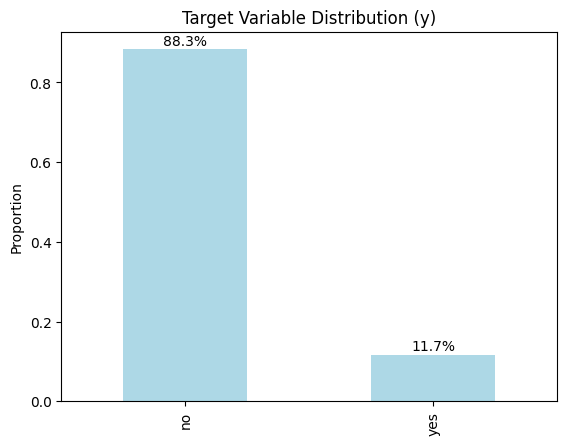

In [9]:
# target variable distribution
ax = bank_full['y'].value_counts(normalize=True).plot(kind='bar', color='lightblue')

plt.title("Target Variable Distribution (y)")
plt.ylabel("Proportion")

# display percentages
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,   
        height + 0.01,                  
        f'{height * 100:.1f}%',        
        ha='center')

plt.show()

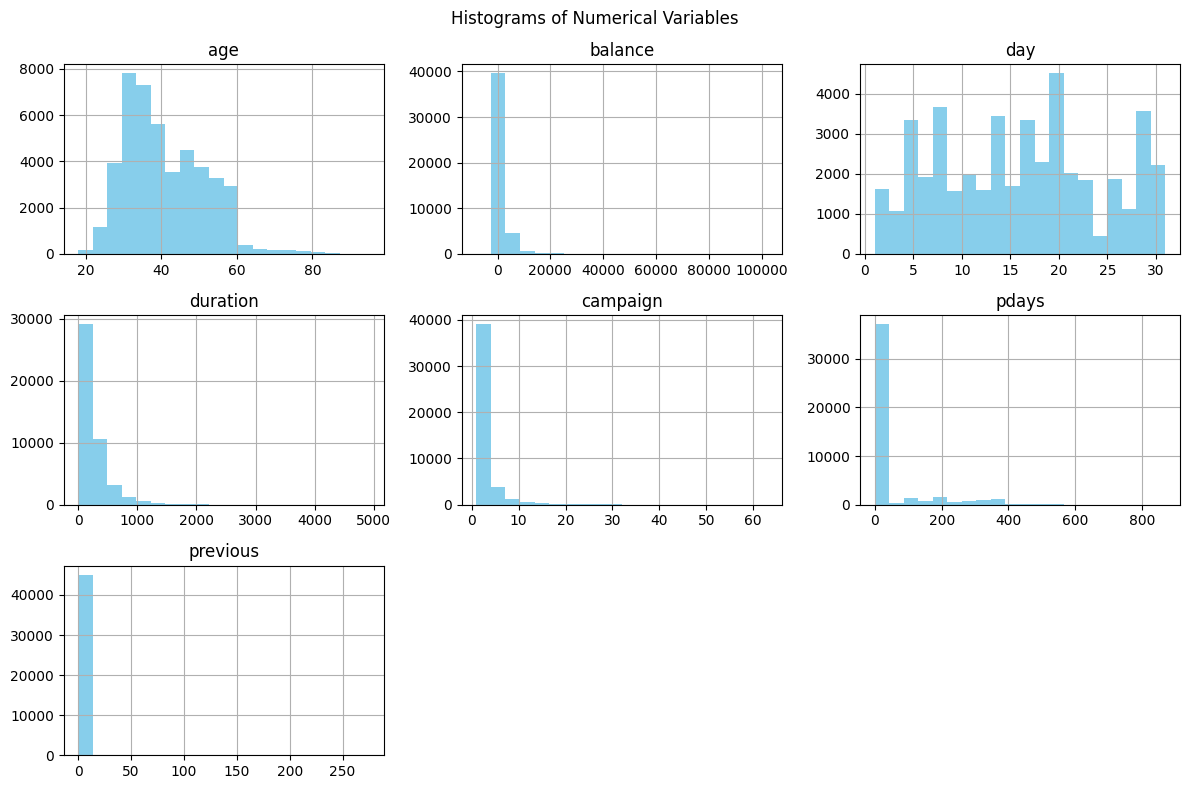

In [10]:
# histogram on numerical variables
num_cols = bank_full.select_dtypes(include=np.number).columns.tolist()
bank_full[num_cols].hist(bins=20, figsize=(12, 8), color='skyblue')
plt.suptitle("Histograms of Numerical Variables")
plt.tight_layout()
plt.show()

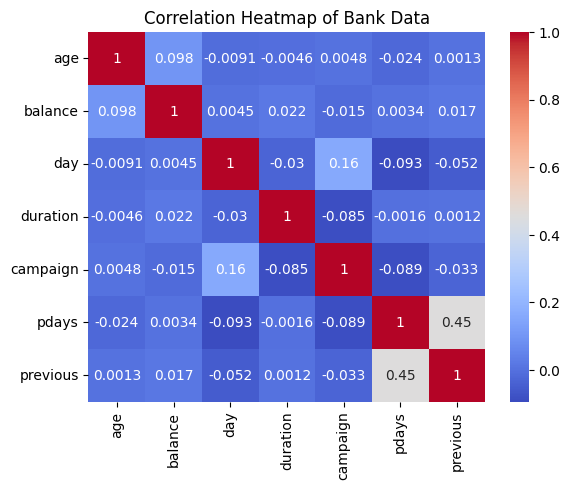

In [11]:
# correlation map
correlation = bank_full.corr(numeric_only=True)
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Bank Data")
plt.show()

## Pre-Processing

In [12]:
# convert the target variable to binary
bank_full['y'] = bank_full['y'].map({'yes': 1, 'no': 0})

# encode the categorical variables
cat_cols = bank_full.select_dtypes(include='object').columns
bank_encoded = pd.get_dummies(bank_full, columns=cat_cols, drop_first=True)

print("Encoded dataset shape:", bank_encoded.shape)

Encoded dataset shape: (45211, 43)


In [13]:
bank_encoded

,age,balance,day,duration,campaign,pdays,previous,y,job_blue-collar,job_entrepreneur,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,58,2143,5,261,1,-1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
1,44,29,5,151,1,-1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
2,33,2,5,76,1,-1,0,0,0,1,...,0,0,0,1,0,0,0,0,0,1
3,47,1506,5,92,1,-1,0,0,1,0,...,0,0,0,1,0,0,0,0,0,1
4,33,1,5,198,1,-1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,825,17,977,3,-1,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
45207,71,1729,17,456,2,-1,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
45208,72,5715,17,1127,5,184,3,1,0,0,...,0,0,0,0,1,0,0,0,1,0
45209,57,668,17,508,4,-1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1


In [14]:
# add constant before the VIF calculation
bank_feature = bank_encoded.drop('y', axis=1)
bank_y = bank_encoded['y']
bank_feature_x = add_constant(bank_feature)
bank_feature_x = bank_feature_x.astype(float)

# calculate the VIF to detect any multicolienarity
vif_data = pd.DataFrame()
vif_data['feature'] = bank_feature_x.columns
vif_data['VIF'] = [variance_inflation_factor(bank_feature_x.values, i) for i in range(bank_feature_x.shape[1])]
vif_df_sorted = vif_data.sort_values('VIF', ascending=False)
vif_df_sorted.head(10)

,feature,VIF
0,const,124.143804
42,poutcome_unknown,6.236080
36,month_may,4.775292
6,pdays,4.678715
34,month_jun,3.514421
22,education_tertiary,3.393155
29,month_aug,3.108190
33,month_jul,3.088580
11,job_management,3.031028
20,marital_single,2.884081


In [15]:
# train/test split
X_train, X_test, y_train, y_test = train_test_split(bank_feature, bank_y, test_size=0.2, random_state=42, stratify=bank_y)
print("Train size:", X_train.shape, "| Test size:", X_test.shape)

Train size: (36168, 42) | Test size: (9043, 42)


### Decision Tree

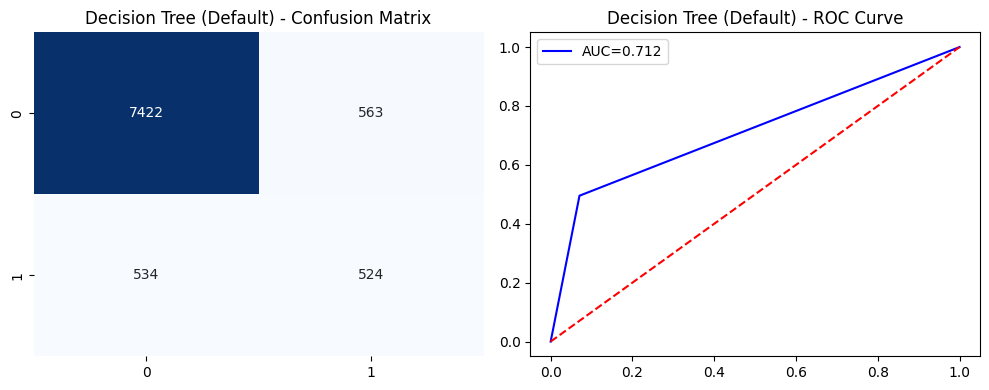

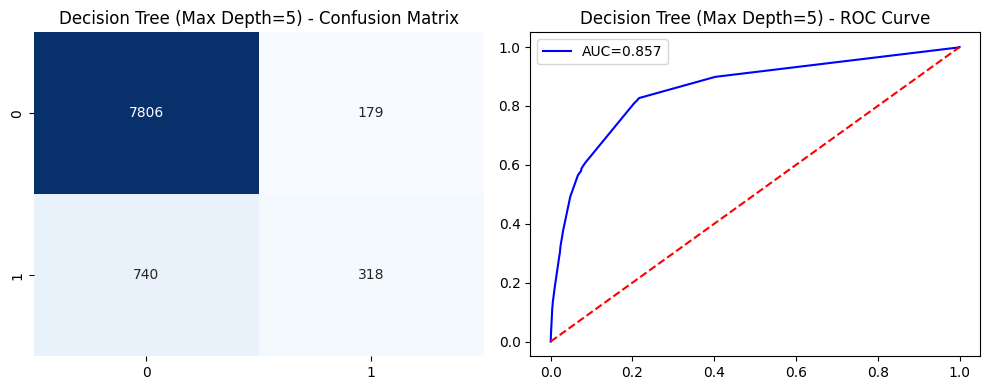

,Model,Accuracy,Precision,Recall,F1,AUC
0,Decision Tree (Default),0.878691,0.482061,0.495274,0.488578,0.712383
1,Decision Tree (Max Depth=5),0.898374,0.639839,0.300567,0.409003,0.857178


In [16]:
# experiment 1: to see the impact of overfitting and generalization from the controlling tree depth
dt_default = DecisionTreeClassifier(random_state=42)
dt_depth5 = DecisionTreeClassifier(max_depth=5, random_state=42)

models = [("Decision Tree (Default)", dt_default),
          ("Decision Tree (Max Depth=5)", dt_depth5)]

results_dt = []

for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    results_dt.append([name, acc, prec, rec, f1, auc])
    
    # Visual
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"{name} - Confusion Matrix")

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.subplot(1,2,2)
    plt.plot(fpr, tpr, label=f"AUC={auc:.3f}", color='blue')
    plt.plot([0,1],[0,1],'r--')
    plt.title(f"{name} - ROC Curve")
    plt.legend()
    plt.tight_layout()
    plt.show()

pd.DataFrame(results_dt, columns=["Model","Accuracy","Precision","Recall","F1","AUC"])



{'Accuracy': 0.8984850160345018, 'Precision': 0.6263537906137184, 'Recall': 0.3279773156899811, 'F1': 0.4305210918114144, 'AUC': 0.849648620463937}


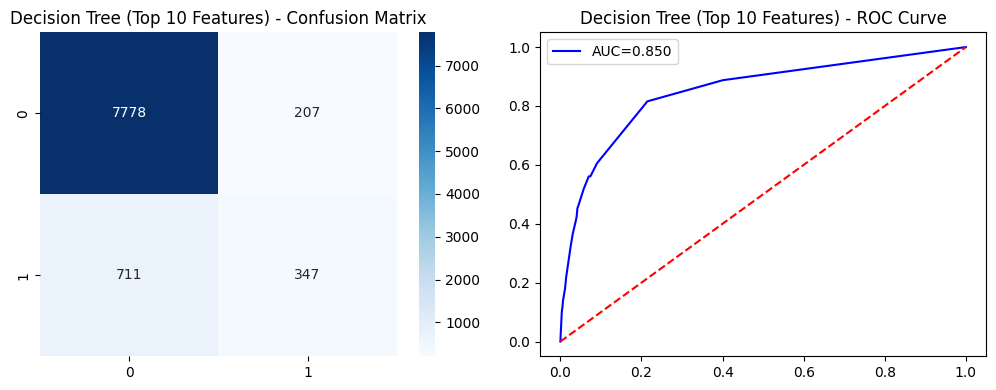

In [17]:
# experiment 2: to see the impact of Top 10 Important Features while simplifying the model
dt_full = DecisionTreeClassifier(random_state=42)
dt_full.fit(X_train, y_train)

feat_imp = pd.Series(dt_full.feature_importances_, index=X_train.columns)
top10 = feat_imp.nlargest(10).index

dt_top10 = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_top10.fit(X_train[top10], y_train)

y_pred = dt_top10.predict(X_test[top10])
y_prob = dt_top10.predict_proba(X_test[top10])[:,1]

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "AUC": roc_auc_score(y_test, y_prob)
}
print(metrics)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Decision Tree (Top 10 Features) - Confusion Matrix")

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.subplot(1,2,2)
plt.plot(fpr, tpr, label=f"AUC={metrics['AUC']:.3f}", color='blue')
plt.plot([0,1],[0,1],'r--')
plt.title("Decision Tree (Top 10 Features) - ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

### Random Forest

In [18]:
# experiment 1: to compare the performance between small and large ensembles
rf10 = RandomForestClassifier(n_estimators=10, random_state=42)
rf100 = RandomForestClassifier(n_estimators=100, random_state=42)

results_rf = []

for name, model in [("Random Forest (10 Trees)", rf10), ("Random Forest (100 Trees)", rf100)]:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    results_rf.append([name, acc, prec, rec, f1, auc])

pd.DataFrame(results_rf, columns=["Model","Accuracy","Precision","Recall","F1","AUC"])


,Model,Accuracy,Precision,Recall,F1,AUC
0,Random Forest (10 Trees),0.901360,0.648746,0.342155,0.448020,0.886252
1,Random Forest (100 Trees),0.905673,0.665056,0.390359,0.491959,0.926569


In [19]:
# experiment 2: to evalulate the model by switching 80/20 to 70/30 Split
X_train70, X_test30, y_train70, y_test30 = train_test_split(bank_feature, bank_y, test_size=0.3, random_state=42, stratify=bank_y)
rf_split = RandomForestClassifier(n_estimators=100, random_state=42)
rf_split.fit(X_train70, y_train70)
y_pred = rf_split.predict(X_test30)
y_prob = rf_split.predict_proba(X_test30)[:,1]

print("Accuracy:", accuracy_score(y_test30, y_pred))
print("F1:", f1_score(y_test30, y_pred))
print("AUC:", roc_auc_score(y_test30, y_prob))

Accuracy: 0.9072544971984665
F1: 0.5011895321173672
AUC: 0.9238277218901867


### AdaBoost

In [20]:
# experiment 1: to analyze the learning rate of the model
ab1 = AdaBoostClassifier(learning_rate=1.0, random_state=42)
ab05 = AdaBoostClassifier(learning_rate=0.5, random_state=42)

results_ab = []
for name, model in [("AdaBoost (LR=1.0)", ab1), ("AdaBoost (LR=0.5)", ab05)]:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    results_ab.append([name, acc, prec, rec, f1, auc])

pd.DataFrame(results_ab, columns=["Model","Accuracy","Precision","Recall","F1","AUC"])

,Model,Accuracy,Precision,Recall,F1,AUC
0,AdaBoost (LR=1.0),0.895278,0.600726,0.312854,0.411436,0.897457
1,AdaBoost (LR=0.5),0.891961,0.643110,0.172023,0.271439,0.889262


In [21]:
# experiment 2: to evaluate the model with Deeper Base Estimator
base_tree = DecisionTreeClassifier(max_depth=3)
ab_deep = AdaBoostClassifier(estimator=base_tree, random_state=42)
ab_deep.fit(X_train, y_train)
y_pred = ab_deep.predict(X_test)
y_prob = ab_deep.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.9023554130266505
Precision: 0.6251788268955651
Recall: 0.41304347826086957
F1: 0.4974388161639158
AUC: 0.9148912244484874


### Summary Comparsion and Metrics

In [22]:
summary = pd.concat([
    pd.DataFrame(results_dt, columns=["Model","Accuracy","Precision","Recall","F1","AUC"]),
    pd.DataFrame(results_rf, columns=["Model","Accuracy","Precision","Recall","F1","AUC"]),
    pd.DataFrame(results_ab, columns=["Model","Accuracy","Precision","Recall","F1","AUC"])
], ignore_index=True)

summary = summary.sort_values(by="Model", ascending=False).reset_index(drop=True)
summary

,Model,Accuracy,Precision,Recall,F1,AUC
0,Random Forest (100 Trees),0.905673,0.665056,0.390359,0.491959,0.926569
1,Random Forest (10 Trees),0.901360,0.648746,0.342155,0.448020,0.886252
2,Decision Tree (Max Depth=5),0.898374,0.639839,0.300567,0.409003,0.857178
3,Decision Tree (Default),0.878691,0.482061,0.495274,0.488578,0.712383
4,AdaBoost (LR=1.0),0.895278,0.600726,0.312854,0.411436,0.897457
5,AdaBoost (LR=0.5),0.891961,0.643110,0.172023,0.271439,0.889262


### Observation and Insights

For this assignment, the purpose is to evaluate three different decision tree models (Decision Tree, Random Forest, AdaBoost) by using the bank marketing dataset. By leveraging the exploratory data analysis from the first assignment, the goal is to determine which model is the best for the bank marketing. Before modeling, the pre-processing will be conducted to ensure the data is ready. The VIF is calculated to detect any multicollinearity as well. With VIF, it is concluded that there is no multicollinearity with each feature. After modeling, evaluation metrics such as Accuracy, Precision, Recall, F1-score, and ROC-AUC were used to assess model performance comprehensively.

For Decision Tree, two experiments were conducted. For the first experiment, the tree's depth was limited to determine if overfitting is reduced and generalization is improved. By limited the depth to 5, it shows that the predictive performance of Decision Tree increased. For the second experiment, the model is simplified with fewer features to determine if the predictive performance decreases or not. It shows that with the simplified model, there was little impact on the predictive performance.

Like Decision Tree, two experiments are conducted on Random Forest. The first experiment focuses on the size of ensemble and to see if a larger size like 100 results in a better performance. The result shows that with larger size, the performance does increase. For the second experiment, the train split of 80/20 changed to 70/30 to determine if the generalization of the model differs. It turns out that there was little impact to the performance. This shows that Random Model is robust across different data patriations.

Two experiments are also conducted on AdaBoost as well. The first experiment compares two learning rates (1.0 and 0.5) to determine the model’s strength. By lowering the learning rate, the model maintains the similar accuracy. However, the AUC shows a slight decrease. For the second experiment, the model is modified with a deep base estimators. The max depth is limited to 3. The goal is to determine if the performance will improve and the result shows a higher accuracy, precision, and AUC than the model with the learning rate of 1.0.

In conclusion, the Random Forest with a larger size of ensemble is best suited for the bank marketing due to its higher predictive performance. The evaluation metrics shows that the model outperforms other 5 models in terms of accuracy, precision, F1 score, recall and AUC.


